In [7]:
import time
from dataclasses import replace
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import random
import sys

ROOT = Path.cwd()
if not (ROOT / "generation").exists() and (ROOT.parent / "generation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
from simulation.arraySim import arrayResponseBatch
from scripts.arrayBatch import ArrayBatch
from scripts.arraySpec import ArraySpec
from scripts.batchFactory import generateBatch
from scripts.coordinateTransforms import mapLLAtoArrayAZEL
from scripts.targetSpec import TargetBatch, TargetLike
from ui.export_target import load_target_from_pt


def _defaultDevice() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def _synchronize(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps" and hasattr(torch.mps, "synchronize"):
        torch.mps.synchronize()


def _saveResults(results: dict[str, Any], savefile: str | Path | None) -> None:
    if savefile is None:
        return

    savePath = Path(savefile)
    if savePath.parent != Path("."):
        savePath.parent.mkdir(parents=True, exist_ok=True)
    torch.save(results, savePath)


def _shapeNumel(shape: tuple[int, ...]) -> int:
    count = 1
    for dim in shape:
        count *= int(dim)
    return count


def _benchmarkArrayResponse(
    batch: ArrayBatch,
    target: TargetLike,
    samples: int,
    chunkSize: int | None = None,
) -> dict[str, Any]:
    if samples <= 0:
        raise ValueError("samples must be a positive integer")
    if chunkSize is not None and chunkSize <= 0:
        raise ValueError("chunkSize must be positive when provided")
    if isinstance(target, TargetBatch) and target.batchSize != batch.batchSize:
        raise ValueError("TargetBatch batch size must match ArrayBatch batch size")

    target = target.to(batch.device, batch.dtype)
    targetArea = torch.stack([target.searchLatitudes, target.searchLongitudes], dim=-1)

    with torch.inference_mode():
        warmupAZEL = mapLLAtoArrayAZEL(batch, targetArea)
        _ = arrayResponseBatch(
            batch,
            warmupAZEL,
            chunkSize=chunkSize,
            dB=False,
            normalize=False,
        )
        _synchronize(batch.device)

        timingsMS: list[float] = []
        lastResponseShape: tuple[int, ...] | None = None
        for _ in range(samples):
            _synchronize(batch.device)
            startTime = time.perf_counter()

            relativeTargetAZEL = mapLLAtoArrayAZEL(batch, targetArea)
            response = arrayResponseBatch(
                batch,
                relativeTargetAZEL,
                chunkSize=chunkSize,
                dB=False,
                normalize=False,
            )

            _synchronize(batch.device)
            timingsMS.append((time.perf_counter() - startTime) * 1000.0)
            lastResponseShape = tuple(response.shape)

    timingTensor = torch.tensor(timingsMS, dtype=torch.float64)
    targetShape = tuple(int(dim) for dim in target.targetShape)
    return {
        "samples": samples,
        "batch_size": batch.batchSize,
        "element_count": batch.N,
        "target_shape": targetShape,
        "target_pixels": _shapeNumel(targetShape),
        "response_shape": lastResponseShape,
        "device": str(batch.device),
        "dtype": str(batch.dtype),
        "chunk_size": chunkSize,
        "metrics_ms": {
            "mean": float(timingTensor.mean().item()),
            "std": float(timingTensor.std(unbiased=False).item()),
            "min": float(timingTensor.min().item()),
            "max": float(timingTensor.max().item()),
            "median": float(timingTensor.median().item()),
            "total": float(timingTensor.sum().item()),
        },
        "timings_ms": timingsMS,
    }


def simBatch(
    batch: ArrayBatch,
    target: TargetLike,
    samples: int,
    savefile: str | Path | None = None,
    chunkSize: int | None = None,
) -> dict[str, Any]:
    results = _benchmarkArrayResponse(
        batch=batch,
        target=target,
        samples=samples,
        chunkSize=chunkSize,
    )
    _saveResults(results, savefile)
    return results


def simSweep(
    baseSpec: ArraySpec,
    baseTarget: TargetLike,
    chunkSizes: list[int | None],
    allowedElementCounts: list[int],
    targetDecimations: list[int],
    experimentName: str,
    samples: int,
    batchSize: int | None = None,
    weightsType: str = "uniform",
    savefile: str | Path | None = None,
    device: torch.device | None = None,
    dtype: torch.dtype | None = torch.float32,
    verbose: bool = True,
) -> dict[str, Any]:
    if not chunkSizes:
        raise ValueError("chunkSizes must contain at least one value")
    if not allowedElementCounts:
        raise ValueError("allowedElementCounts must contain at least one value")
    if not targetDecimations:
        raise ValueError("targetDecimations must contain at least one value")

    if batchSize is None:
        batchSize = baseTarget.batchSize if isinstance(baseTarget, TargetBatch) else 1
    if isinstance(baseTarget, TargetBatch) and batchSize != baseTarget.batchSize:
        raise ValueError("batchSize must match TargetBatch.batchSize for batched targets")

    if device is None:
        device = _defaultDevice()

    records: list[dict[str, Any]] = []
    experimentCount = len(chunkSizes) * len(allowedElementCounts) * len(targetDecimations)
    experimentIndex = 0

    for chunkSize in chunkSizes:
        for requestedElementCount in allowedElementCounts:
            for targetDecimation in targetDecimations:
                experimentIndex += 1
                if targetDecimation <= 0:
                    raise ValueError("targetDecimations must contain only positive integers")

                if verbose:
                    print(
                        f"[{experimentIndex}/{experimentCount}] "
                        f"chunkSize={chunkSize} "
                        f"allowedElementCount={requestedElementCount} "
                        f"targetDecimation={targetDecimation}"
                    )

                sweepSpec = replace(baseSpec, allowedElementCount=(int(requestedElementCount),))
                sweepTarget = baseTarget.decimate(int(targetDecimation))
                sweepBatch = generateBatch(
                    sweepSpec,
                    batchSize=batchSize,
                    device=device,
                    dtype=dtype,
                    elementCount=int(requestedElementCount),
                    weightsType=weightsType,
                )

                benchmark = simBatch(
                    batch=sweepBatch,
                    target=sweepTarget,
                    samples=samples,
                    savefile=None,
                    chunkSize=chunkSize,
                )

                record = {
                    "experiment_name": experimentName,
                    "chunk_size": chunkSize,
                    "requested_element_count": int(requestedElementCount),
                    "actual_element_count": int(sweepBatch.N),
                    "target_decimation": int(targetDecimation),
                    "target_shape": benchmark["target_shape"],
                    "target_pixels": benchmark["target_pixels"],
                    "mean_ms": benchmark["metrics_ms"]["mean"],
                    "std_ms": benchmark["metrics_ms"]["std"],
                    "min_ms": benchmark["metrics_ms"]["min"],
                    "max_ms": benchmark["metrics_ms"]["max"],
                    "median_ms": benchmark["metrics_ms"]["median"],
                    "total_ms": benchmark["metrics_ms"]["total"],
                    "benchmark": benchmark,
                }
                records.append(record)

    results = {
        "experiment_name": experimentName,
        "samples": samples,
        "batch_size": batchSize,
        "weights_type": weightsType,
        "device": str(device),
        "dtype": str(dtype),
        "sweep_parameters": {
            "chunk_sizes": chunkSizes,
            "allowed_element_counts": [int(value) for value in allowedElementCounts],
            "target_decimations": [int(value) for value in targetDecimations],
        },
        "records": records,
    }
    _saveResults(results, savefile)
    return results


def _loadSweepResults(sweepResults: dict[str, Any] | str | Path) -> dict[str, Any]:
    if isinstance(sweepResults, (str, Path)):
        return torch.load(sweepResults, weights_only=False)
    return sweepResults


def plotSweepResults(
    sweepResults: dict[str, Any] | str | Path,
    metric: str = "mean_ms",
    aggregate: str = "mean",
    baselineSavefile: str | Path | None = None,
) -> tuple:
    sweepResults = _loadSweepResults(sweepResults)
    baselineResults = None
    if baselineSavefile is not None:
        baselineResults = _loadSweepResults(baselineSavefile)

    records = sweepResults.get("records", [])
    if not records:
        raise ValueError("sweepResults does not contain any records")
    if metric not in records[0]:
        raise ValueError(f"metric '{metric}' is not present in sweep records")
    if aggregate not in {"mean", "min", "max"}:
        raise ValueError("aggregate must be one of: 'mean', 'min', 'max'")

    baselineRecords: list[dict[str, Any]] = []
    baselineLabel: str | None = None
    if baselineResults is not None:
        baselineRecords = baselineResults.get("records", [])
        if not baselineRecords:
            raise ValueError("baselineSavefile does not contain any sweep records")
        if metric not in baselineRecords[0]:
            raise ValueError(f"metric '{metric}' is not present in baseline sweep records")
        baselineLabel = baselineResults.get("experiment_name", Path(baselineSavefile).stem)

    def reduceValues(values: list[float]) -> float:
        if aggregate == "mean":
            return sum(values) / len(values)
        if aggregate == "min":
            return min(values)
        return max(values)

    figure, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
    plotSpecs = [
        (
            "chunk_size",
            "Chunk Size",
            lambda record: "auto" if record["chunk_size"] is None else str(record["chunk_size"]),
        ),
        (
            "requested_element_count",
            "Allowed Element Count",
            lambda record: str(record["requested_element_count"]),
        ),
        (
            "target_decimation",
            "Target Decimation",
            lambda record: f"{record['target_decimation']}\\n({record['target_pixels']} px)",
        ),
    ]

    currentLabel = sweepResults.get("experiment_name", "Current Sweep")

    for axis, (field, title, labelFn) in zip(axes, plotSpecs):
        grouped: dict[Any, list[float]] = {}
        labelLookup: dict[Any, str] = {}
        for record in records:
            key = record[field]
            grouped.setdefault(key, []).append(float(record[metric]))
            labelLookup[key] = labelFn(record)

        baselineGrouped: dict[Any, list[float]] = {}
        for record in baselineRecords:
            key = record[field]
            baselineGrouped.setdefault(key, []).append(float(record[metric]))
            labelLookup.setdefault(key, labelFn(record))

        sortedKeys = sorted(
            set(grouped) | set(baselineGrouped),
            key=lambda value: float("inf") if value is None else float(value),
        )
        xPositions = list(range(len(sortedKeys)))
        yValues = [reduceValues(grouped[key]) if key in grouped else float("nan") for key in sortedKeys]

        axis.plot(xPositions, yValues, marker="o", linewidth=2, label=currentLabel)

        if baselineRecords:
            baselineYValues = [
                reduceValues(baselineGrouped[key]) if key in baselineGrouped else float("nan")
                for key in sortedKeys
            ]
            axis.plot(
                xPositions,
                baselineYValues,
                marker="s",
                linestyle="--",
                linewidth=2,
                label=baselineLabel,
            )

        axis.set_xticks(xPositions)
        axis.set_xticklabels([labelLookup[key] for key in sortedKeys], rotation=25)
        axis.set_title(title)
        axis.set_xlabel(title)
        axis.set_ylabel(metric.replace("_", " "))
        axis.grid(True, alpha=0.3)
        if baselineRecords:
            axis.legend()

    title = f"{currentLabel} ({aggregate} {metric})"
    if baselineLabel is not None:
        title = f"{title} vs {baselineLabel}"
    figure.suptitle(title)
    plt.show()
    return figure, list(axes)


# Example single benchmark:
# device = _defaultDevice()
# dtype = torch.float32
# target = load_target_from_pt(ROOT / "target_spec.pt")
# spec = ArraySpec(
#     geometry="UCA",
#     allowedAspectRatio=[1],
#     allowedElementCount=[1_000],
#     latitudeRange=(15, 15),
#     altitudeRange=(7e6, 7e6),
# )
# batch = generateBatch(spec, batchSize=1, device=device, dtype=dtype, weightsType="uniform")
# simBatch(batch, target.decimate(4), samples=10, savefile=None)

# Example sweep:
# sweep = simSweep(
#     baseSpec=spec,
#     baseTarget=target,
#     chunkSizes=[None, 250_000, 1_000_000],
#     allowedElementCounts=[256, 512, 1_000],
#     targetDecimations=[2, 4, 8],
#     experimentName="uca_speed_sweep",
#     samples=5,
#     batchSize=1,
#     weightsType="uniform",
#     savefile="benchmarks/uca_speed_sweep.pt",
# )
# plotSweepResults(sweep)


In [ ]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Setup device and precision
dtype = torch.float32
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")



# spec = ArraySpec(failRate=0.05, positionJitterSTD=0.01, phaseJitterSTD=0.1)
spec = ArraySpec(geometry="UCA", allowedAspectRatio=[1], allowedElementCount=[10_000], latitudeRange=(15,15), altitudeRange=(7e6, 7e6))
random = generateBatch(spec, batchSize=50, device=device, dtype=dtype, weightsType="random")
target = load_target_from_pt("../target_spec.pt")
batch = generateBatch(spec, batchSize=1, device=device, dtype=dtype, weightsType="uniform")
#simBatch(batch, target.decimate(4), samples=10, savefile=None)

#Example sweep:
sweep = simSweep(
    baseSpec=spec,
    baseTarget=target,
    chunkSizes=[100_000_000],
    allowedElementCounts=[1_000, 5_000, 10_000, 50_000],
    targetDecimations=[4, 6],
    experimentName="pbias_speed_auto",
    samples=5,
    batchSize=10,
    weightsType="random",
    savefile="benchmarks/pbias_speed_auto.pt",
)
plotSweepResults(sweep)

[1/4] chunkSize=100000000 allowedElementCount=1000 targetDecimation=6
[2/4] chunkSize=100000000 allowedElementCount=5000 targetDecimation=6
[3/4] chunkSize=100000000 allowedElementCount=10000 targetDecimation=6
[4/4] chunkSize=100000000 allowedElementCount=50000 targetDecimation=6


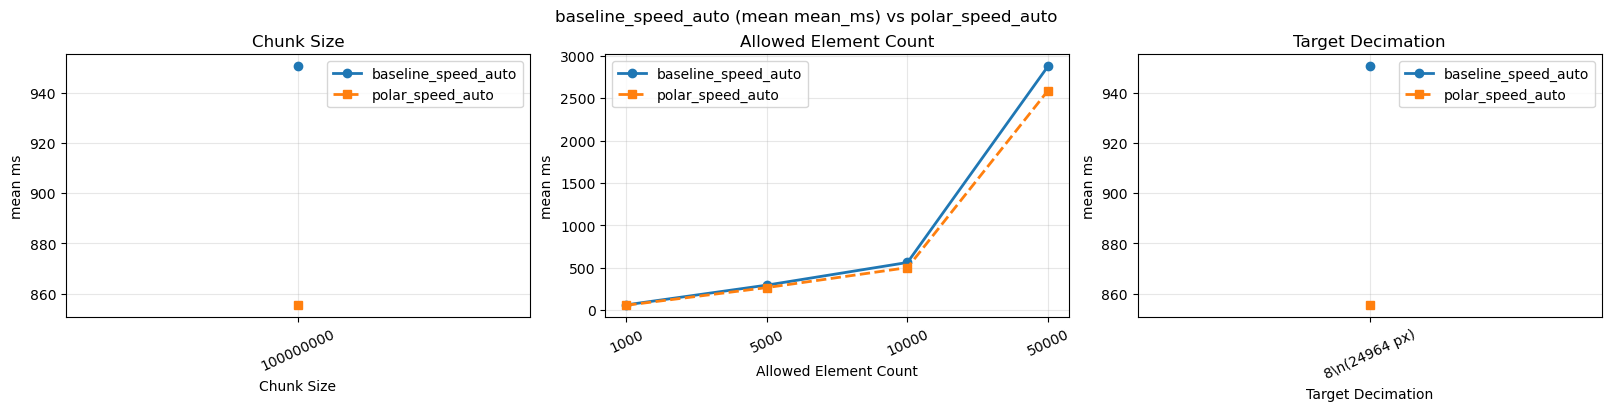

(<Figure size 1600x400 with 3 Axes>,
 [<Axes: title={'center': 'Chunk Size'}, xlabel='Chunk Size', ylabel='mean ms'>,
  <Axes: title={'center': 'Allowed Element Count'}, xlabel='Allowed Element Count', ylabel='mean ms'>,
  <Axes: title={'center': 'Target Decimation'}, xlabel='Target Decimation', ylabel='mean ms'>])

In [ ]:
plotSweepResults(sweep, baselineSavefile="benchmarks/split_speed_auto.pt")
